In [2]:
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["taller4_db"]
collection = db["raw_data"]

print(f"Documentos en MongoDB: {collection.count_documents({})}")

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


Documentos en MongoDB: 121


In [3]:
documentos = list(collection.find({}, {"_id": 0}))
df_raw = pd.DataFrame(documentos)

print("Columnas disponibles:", df_raw.columns.tolist())
print(f"Shape: {df_raw.shape}")

Columnas disponibles: ['id', 'name', 'ki', 'maxKi', 'race', 'gender', 'description', 'image', 'affiliation', 'deletedAt', '_tipo', 'isDestroyed']
Shape: (121, 12)


In [7]:
columnas = ["name", "race", "gender", "affiliation", "_tipo"]
df_raw2 = df_raw[columnas].copy().rename(columns={"_tipo": "tipo"})

# Filtrar solo personajes (tienen los campos más completos)
df = df_raw2[df_raw2["tipo"] == "personaje"].copy()
df = df.fillna("Desconocido")
df = df.reset_index(drop=True)

print(f"Registros de personajes: {len(df)}")
print(df.head(10))

Registros de personajes: 58
      name         race  gender     affiliation       tipo
0     Goku       Saiyan    Male       Z Fighter  personaje
1   Vegeta       Saiyan    Male       Z Fighter  personaje
2  Piccolo     Namekian    Male       Z Fighter  personaje
3    Bulma        Human  Female       Z Fighter  personaje
4  Freezer  Frieza Race    Male  Army of Frieza  personaje
5   Zarbon  Frieza Race    Male  Army of Frieza  personaje
6  Dodoria  Frieza Race    Male  Army of Frieza  personaje
7    Ginyu  Frieza Race    Male  Army of Frieza  personaje
8   Celula      Android    Male      Freelancer  personaje
9    Gohan       Saiyan    Male       Z Fighter  personaje


In [5]:
print("=== TIPOS DE DATOS ===")
df.info()

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS GENERALES ===")
print(df.describe())

=== TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         121 non-null    str  
 1   race         121 non-null    str  
 2   gender       121 non-null    str  
 3   affiliation  121 non-null    str  
 4   tipo         121 non-null    str  
dtypes: str(5)
memory usage: 4.9 KB

=== VALORES NULOS ===
name           0
race           0
gender         0
affiliation    0
tipo           0
dtype: int64

=== ESTADÍSTICAS GENERALES ===
          name         race       gender  affiliation       tipo
count      121          121          121          121        121
unique     120           14            3            9          3
top     Vegeta  Desconocido  Desconocido  Desconocido  personaje
freq         2           63           63           63         58


In [8]:
# Insight 1: Total de personajes analizados
print(f"=== INSIGHT 1: Total personajes ===")
print(f"Se analizaron {len(df)} personajes del universo Dragon Ball")

# Insight 2: Raza más común
raza_top = df["race"].value_counts().idxmax()
print(f"\n=== INSIGHT 2: Raza más frecuente ===")
print(f"{raza_top} con {df['race'].value_counts().max()} personajes")
print(df["race"].value_counts())

# Insight 3: Distribución por género
print(f"\n=== INSIGHT 3: Distribución por género ===")
print(df["gender"].value_counts())
male = df["gender"].value_counts().get("Male", 0)
female = df["gender"].value_counts().get("Female", 0)
print(f"Ratio: {male} hombres vs {female} mujeres")

# Insight 4: Afiliación más común
print(f"\n=== INSIGHT 4: Afiliaciones ===")
print(df["affiliation"].value_counts())

# Insight 5: Razas únicas
print(f"\n=== INSIGHT 5: Diversidad de razas ===")
print(f"Hay {df['race'].nunique()} razas distintas: {df['race'].unique().tolist()}")

=== INSIGHT 1: Total personajes ===
Se analizaron 58 personajes del universo Dragon Ball

=== INSIGHT 2: Raza más frecuente ===
Saiyan con 10 personajes
race
Saiyan              10
Android              9
Human                8
Nucleico benigno     7
God                  5
Frieza Race          4
Nucleico             4
Namekian             3
Angel                3
Majin                2
Unknown              1
Jiren Race           1
Evil                 1
Name: count, dtype: int64

=== INSIGHT 3: Distribución por género ===
gender
Male      51
Female     7
Name: count, dtype: int64
Ratio: 51 hombres vs 7 mujeres

=== INSIGHT 4: Afiliaciones ===
affiliation
Z Fighter               19
Other                   18
Villain                  9
Army of Frieza           5
Pride Troopers           4
Freelancer               1
Assistant of Beerus      1
Assistant of Vermoud     1
Name: count, dtype: int64

=== INSIGHT 5: Diversidad de razas ===
Hay 13 razas distintas: ['Saiyan', 'Namekian', 'Human', 

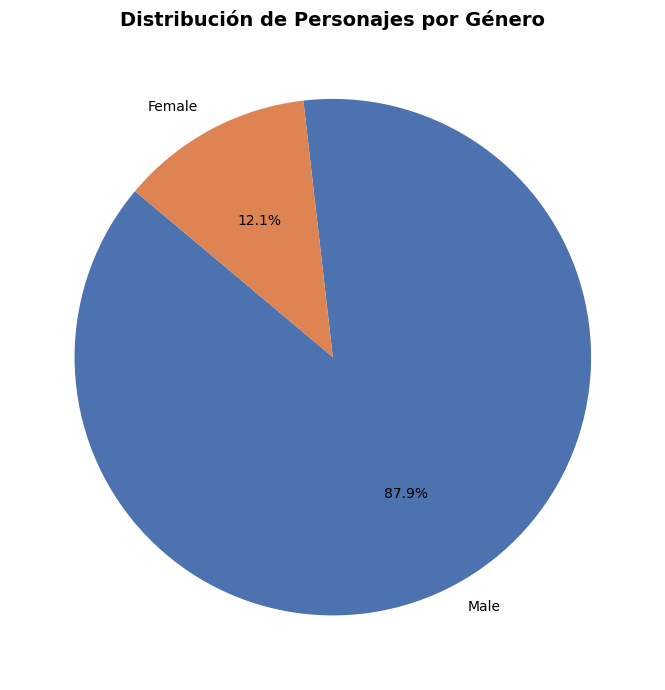

In [9]:
genero_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(genero_counts, labels=genero_counts.index, autopct='%1.1f%%',
        colors=["#4C72B0", "#DD8452"], startangle=140)
plt.title("Distribución de Personajes por Género", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("grafico_torta_genero.png", dpi=150)
plt.show()

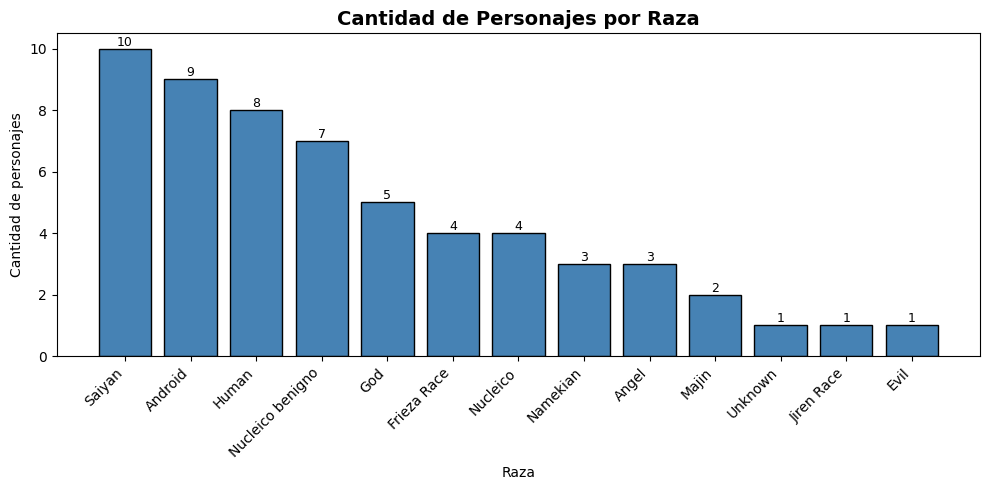

In [10]:
raza_counts = df["race"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(raza_counts.index, raza_counts.values, color="steelblue", edgecolor="black")
plt.title("Cantidad de Personajes por Raza", fontsize=14, fontweight='bold')
plt.xlabel("Raza")
plt.ylabel("Cantidad de personajes")
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("grafico_barras_razas.png", dpi=150)
plt.show()

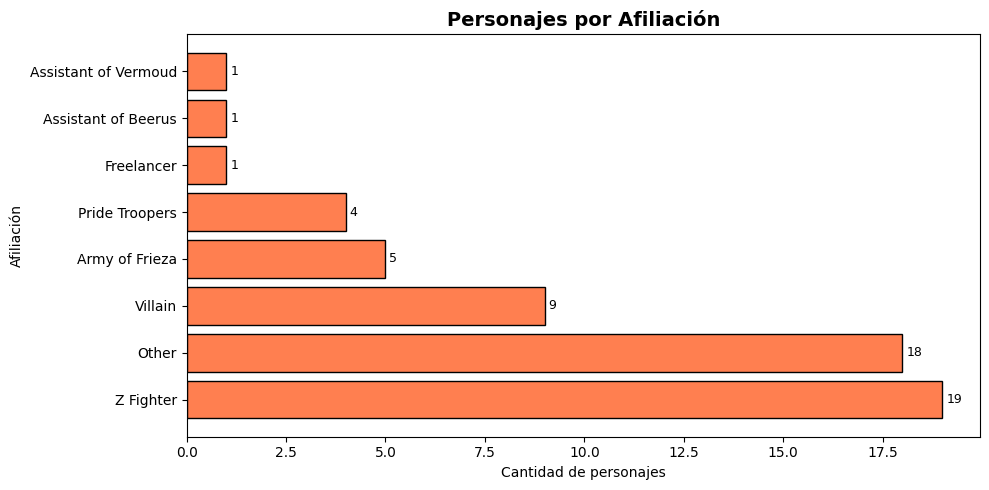

In [12]:
afil_counts = df["affiliation"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(afil_counts.index, afil_counts.values, color="coral", edgecolor="black")
plt.title("Personajes por Afiliación", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de personajes")
plt.ylabel("Afiliación")
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig("grafico_barras_afiliaciones.png", dpi=150)
plt.show()

## Conclusiones

El análisis de 58 personajes del universo Dragon Ball revela que los **Saiyans** dominan con 10 representantes, seguidos de Androids (9) y Humanos (8). El universo es predominantemente masculino (87.9%) con solo 7 personajes femeninos. Los **Z Fighters** son el grupo más numeroso con 19 miembros, y existen 13 razas distintas lo que refleja la diversidad del universo Dragon Ball.